[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open      Volume
Ticker     RELIANCE.NS RELIANCE.NS RELIANCE.NS RELIANCE.NS RELIANCE.NS
Date                                                                  
2020-01-01      672.22      680.01      670.39      675.96    14004468
2020-01-02      683.66      686.18      673.28      673.28    17710316
2020-01-03      684.48      686.49      678.18      682.64    20984698
2020-01-06      668.61      680.37      667.05      676.85    24519177
2020-01-07      678.90      683.30      673.95      676.40    16683622


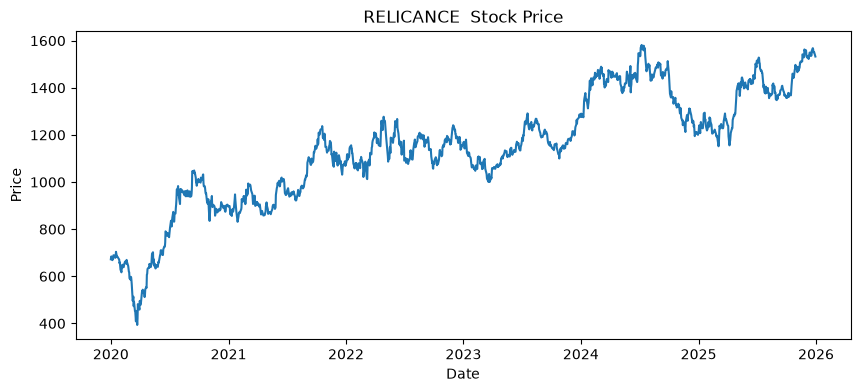

X shape: (1483, 3)
y shape: (1483,)
[1347.27 1356.96 1332.18 1326.06 1327.83 1316.41 1322.16 1328.29 1332.14
 1320.63 1326.41 1291.55 1292.82 1313.5  1295.13 1272.4  1261.25 1262.9
 1241.7  1255.8  1250.46 1231.14 1212.36 1253.31 1276.72 1284.92 1282.25
 1260.11 1280.   1298.07 1311.96 1298.14 1309.84 1300.62 1283.84 1273.4
 1266.95 1252.07 1261.27 1257.72 1234.87 1241.72 1220.56 1194.87 1210.95
 1212.85 1206.36 1210.45 1200.76 1204.79]
RMSE: 16.35
Accuracy :  99.08
Error :  0.92


In [2]:
import yfinance as yf
import matplotlib.pyplot as plt

data = yf.download("RELIANCE.NS", start="2020-01-01", end="2025-12-31")

print(data.head().round(2))

plt.figure(figsize=(10,4))
plt.plot(data['Close'])
plt.title("RELICANCE  Stock Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()
import numpy as np

close_data = data['Close'].values

X = []
y = []

window_size = 3 

for i in range(len(close_data) - window_size):
    X.append(close_data[i:i+window_size])
    y.append(close_data[i+window_size])

X = np.array(X)
y = np.array(y)

X=X.reshape(X.shape[0],X.shape[1])
y=y.ravel()
print("X shape:", X.shape)
print("y shape:", y.shape)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)
print(predictions[:50].round(2))
from sklearn.metrics import mean_squared_error
import numpy as np

mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
print("RMSE:", rmse.round(2))
errorPercentage = np.mean(np.abs((predictions-y_test)/y_test))*100
print("Accuracy : ",100-errorPercentage.round(2))
print("Error : ", errorPercentage.round(2))